# Belief-State Geometry in a Transformer's Residual Stream — Mess3

Replication of the headline result of **Shai, Marzen, Teixeira, Gietelink Oldenziel & Riechers (2024)**, *Transformers Represent Belief State Geometry in their Residual Stream* ([arXiv:2405.15943](https://arxiv.org/abs/2405.15943)).

**The claim.** A small transformer trained *only* to predict the next token of sequences from a Hidden Markov Model develops, in its residual stream, a *linearly decodable* representation of the optimal Bayesian **belief state** — the distribution over the HMM's **hidden states** given the observation history. For the **Mess3** process this belief lives in a 2-simplex (a triangle) and the set of reachable beliefs is an infinite **fractal**, predicted *in advance* from the data-generating process.

**The crux (don't get this wrong).** The probe target is the belief over *hidden states*, **not** the next-token distribution. The next-token distribution is a (lossy) function of the belief; regressing onto it would replicate the wrong thing.

In [1]:
# Make src/ importable and use inline figures.
import sys; sys.path.insert(0, "../src")
%matplotlib inline
import numpy as np
from pathlib import Path


## 1. Train (or load) the model
Architecture matches the paper (App. A.4): 4 layers, d_model=64, 1 head, d_head=8, d_mlp=256, n_ctx=10, LayerNorm, ReLU, causal. We use a laptop-friendly Adam recipe that reaches the same loss floor as the paper's 1M-step SGD run; the deviation is documented in the README. Belief recovery is a property of the *converged* model, not of the optimiser.

In [2]:
from hmms import Mess3
from train import train, TrainConfig, save_checkpoint

ckpt_path = Path('../checkpoints/mess3_fast.pt')
if not ckpt_path.exists():
    res = train(Mess3(), train_cfg=TrainConfig.fast(n_steps=10000, device='cpu'),
                process_name='mess3')
    save_checkpoint(res, ckpt_path)
else:
    print('Using existing checkpoint:', ckpt_path)

Using existing checkpoint: ../checkpoints/mess3_fast.pt


## 2. Probe the residual stream and build the figures
`run_mess3_experiment` caches `blocks.{l}.hook_resid_post` at every position, fits a plain linear map (OLS) from the 64-dim activations to the 3-dim analytic belief, and evaluates R² on a **held-out** sample. It writes the figures and `results/metrics_mess3.json`.

Moving model to device:  mps


final-layer R²      : 0.9886
R² per layer        : {'0': 0.988, '1': 0.989, '2': 0.988, '3': 0.989}
final loss (nats)   : 0.804
optimal floor (nats): 0.8036


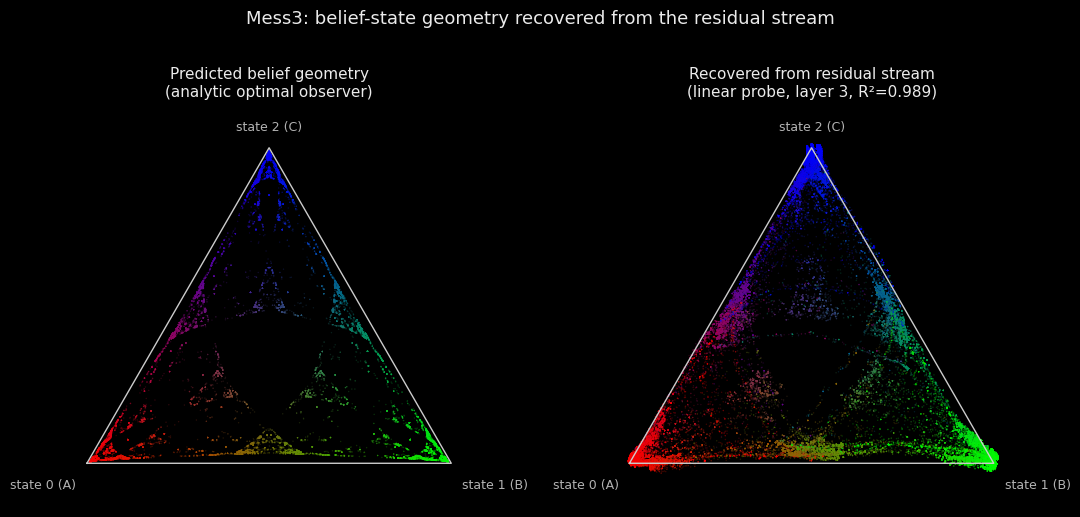

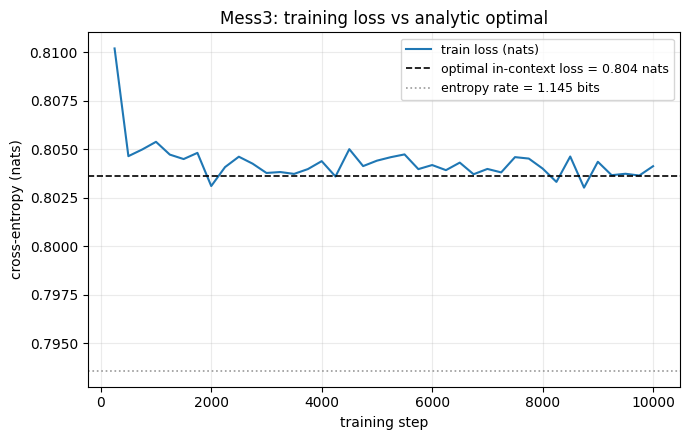

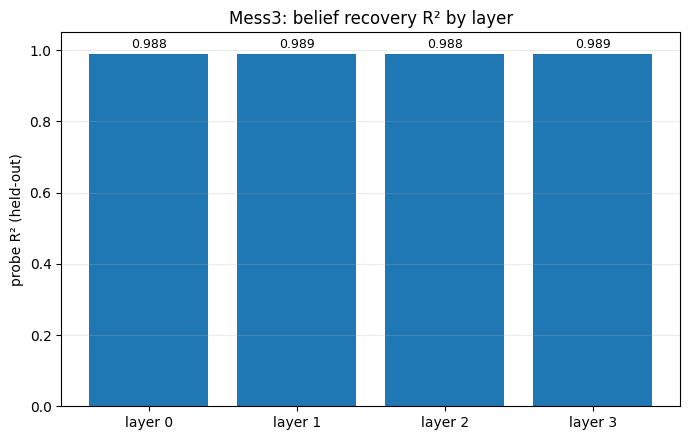

In [3]:
from experiments import run_mess3_experiment
out = run_mess3_experiment('../checkpoints/mess3_fast.pt', save=True)
m = out['metrics']
print('final-layer R²      :', round(m['probe']['r2_headline_layer'], 4))
print('R² per layer        :', {k: round(v,3) for k,v in m['probe']['r2_per_layer'].items()})
print('final loss (nats)   :', round(m['training']['final_loss_nats'], 4))
print('optimal floor (nats):', round(m['training']['optimal_in_context_loss_nats'], 4))

## 3. The headline figure
**Left:** the analytic Mess3 belief fractal (optimal observer). **Right:** the belief decoded linearly from the residual stream. Both are coloured by the *true* belief (RGB = belief coordinates), so a visual match is a like-for-like result.

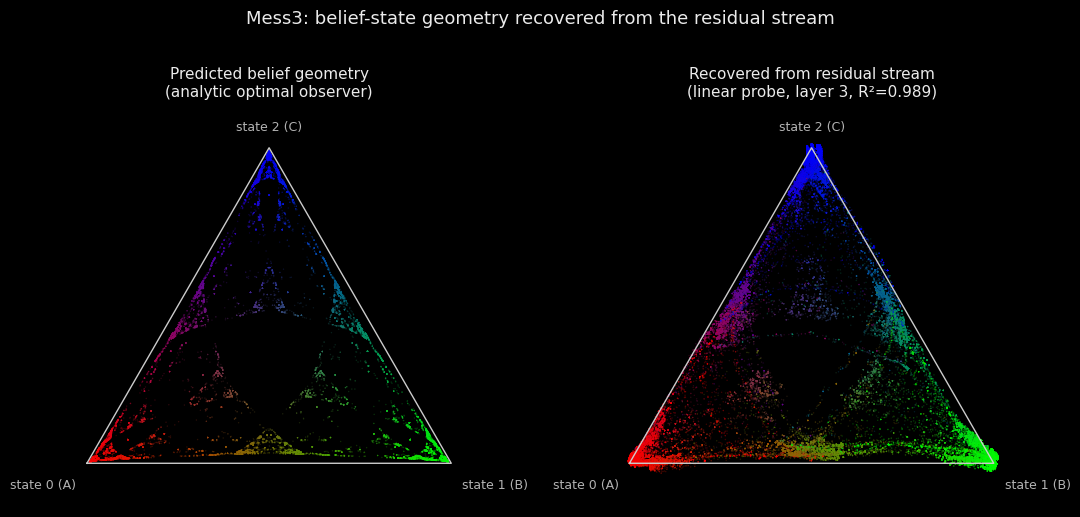

In [4]:
out['figures']['headline']

## 4. Training converged to the information-theoretic floor

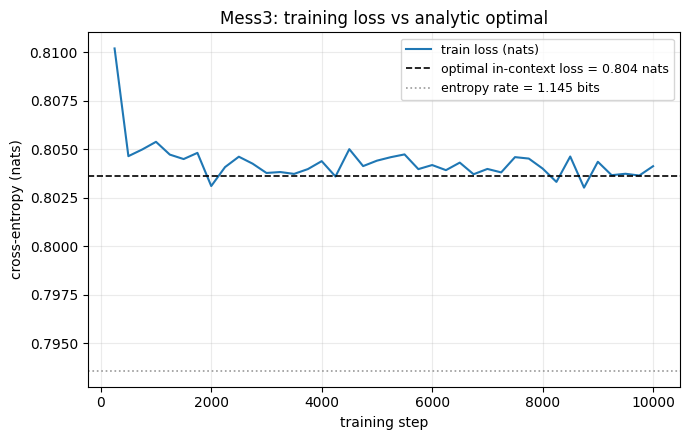

In [5]:
out['figures']['training_curve']

## 5. Which layer carries the geometry?
For Mess3 the belief is recoverable from the final residual stream (the paper's finding). RRXOR — where the representation is *distributed across layers* — is in `02_rrxor_layers.ipynb`.

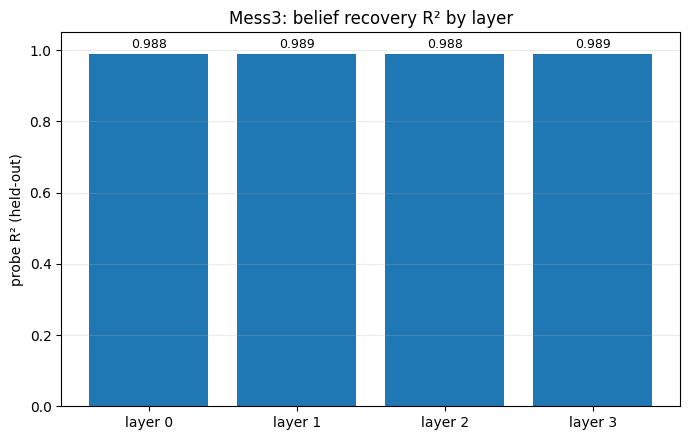

In [6]:
out['figures']['layer_r2']